# Configuração do Ambiente Virtual

Siga as instruções abaixo para configurar o ambiente deste notebook:

1. **Execute a célula de código abaixo.** Ela usará o `uv` para criar um ambiente virtual (`.venv`) e instalará as bibliotecas necessárias, incluindo o `ipykernel`.
2. **Execute um Reload Window** (Ctrl+Shift+P → Developer: Reload Window).
3. **Troque o Kernel do Notebook no VS Code:**
   * Após a execução concluir, clique no nome do Kernel atual, no **canto superior direito** da janela do notebook.
   * Escolha **"Select Another Kernel..."** (Selecionar Outro Kernel).
   * Selecione **"Python Environments"** (Ambientes Python).
   * Escolha o Python que está dentro da pasta `.venv` que acabou de ser criada (ex: `./.venv/bin/python`).
4. **Pronto!** Agora você pode executar as próximas células de análise de dados sem problemas de dependências.

In [1]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv

# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
!uv venv --clear

# Instala as bibliotecas necessárias
!uv pip install pandas numpy matplotlib scikit-learn imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


c:\Users\Yuri Factor\OneDrive\Área de Trabalho\UNICEP\ML\.venv\Scripts\python.exe: No module named pip
'uv' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.
'uv' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [3]:
!uv pip install ipykernel

'uv' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [4]:
!uv run python -m ipykernel install --user --name aula-03 --display-name "cursos-eng-dados-churn(uv)"


'uv' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


# Data Preparation Pipeline for Machine Learning
## Case Study: Bank Customer Churn — Previsão de Evasão Bancária (Kaggle)

> **Contexto:** Um banco europeu com operações em 3 países (`France`, `Germany`, `Spain`) quer descobrir o perfil de clientes que fecham a conta e abandonam a instituição. Nosso Target é `Exited` (1 = saiu do banco / 0 = permaneceu).

Etapas:
1. Análise dos Dados (EDA)
2. Limpeza de Dados (remoção de colunas irrelevantes + tratamento de nulos)
3. Tratamento de Outliers
4. Transformações Estatísticas (StandardScaler)
5. Encoding de Variáveis Categóricas (One-Hot Encoding)
6. Seleção de Features
7. Split do Dataset e Balanceamento com SMOTE


![imagem](../aula-01-prepa-dados/image/pipeline-pre-processamento.jpg)


A imagem divide o pipeline em duas macrofases (Fase 1: Exploração e Saneamento / Fase 2: Engenharia e Estruturação) e abriga os 7 passos descritos da seguinte forma:

Na **Fase 1: Exploração e Saneamento**:

*   A bolha amarela do topo (**EDA e Limpeza Inicial**): Contempla perfeitamente as etapas **1 (Análise dos Dados - EDA)** e **2 (Limpeza de Dados)**. O texto nela diz: "Compreensão visual dos dados seguida da correção de erros e valores ausentes".
*   A bolha verde-água inferior (**Tratamento de Outliers**): Reflete de forma direta a etapa **3 (Tratamento de Outliers)**.

Na **Fase 2: Engenharia e Estruturação**:

*   A engrenagem laranja superior (**Transformações e Encoding**): Agrupa logicamente as etapas **4 (Transformações Estatísticas)** e **5 (Encoding de Variáveis Categóricas)**.
*   A balança vermelha inferior (**Seleção e Split Final**): Sintetiza a etapa **6 (Seleção de Features)** e engloba perfeitamente a etapa **7 (Split do Dataset e Balanceamento)**.

Por fim, a etapa resultante pós-split é direcionada para a base cilíndrica verde de **"Treinamento"** (onde é feito o balanceamento via SMOTE) e outra para o **"Teste"**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE

# Carregar Dataset

In [4]:
df = pd.read_csv('Customer-Churn-Records.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# 1. Análise Exploratória (EDA)

**Observação do Professor:**
Para iniciarmos nossa Análise Exploratória de Dados (EDA), o primeiro passo é sempre entender a estrutura dos dados.

A função `df.info()` nos mostra que o dataset de Churn Bancário é bastante limpo — a maioria das colunas não possui valores nulos. Isso é comum em dados extraídos de sistemas bancários, que costumam ter alta integridade.

No entanto, atenção especial às seguintes colunas:
- **`RowNumber`, `CustomerId`, `Surname`**: Identificadores administrativos sem poder preditivo. A regra de ouro de Engenharia de Dados diz: **"IDs não preveem comportamento"**. Essas colunas serão removidas na limpeza.
- **`Geography`**: País do cliente (`France`, `Germany`, `Spain`). Variável **categórica** que exige encoding.
- **`Gender`**: Gênero do cliente (`Male`/`Female`). Variável **categórica binária** que exige encoding.
- **`Balance`** e **`EstimatedSalary`**: Features numéricas com magnitudes muito altas que precisarão do `StandardScaler`.
- **`Exited`**: Nossa **variável alvo** (target). Note o **desbalanceamento severo**: cerca de 80% dos clientes **não** saem do banco (classe 0), enquanto ~20% saem (classe 1). Isso exige o uso do **SMOTE** na etapa final!

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

**Dicionário de Dados (Significado das Features):**

*   **`0. RowNumber`**: Número sequencial de linha no dataset. Sem valor analítico — será removido.
*   **`1. CustomerId`**: ID único do cliente no sistema bancário. Sem valor preditivo — será removido.
*   **`2. Surname`**: Sobrenome do cliente. Sem relação com comportamento de churn — será removido.
*   **`3. CreditScore`**: Pontuação de crédito do cliente. Variável **numérica** — clientes com score mais alto tendem a ter menor churn.
*   **`4. Geography`**: País onde a conta está domiciliada (`France`, `Germany`, `Spain`). Variável **categórica** — exige One-Hot Encoding.
*   **`5. Gender`**: Gênero do cliente (`Male`/`Female`). Variável **categórica binária** — exige encoding.
*   **`6. Age`**: Idade do cliente. Variável **numérica** — clientes mais velhos tendem a ter maior churn.
*   **`7. Tenure`**: Há quantos anos o cliente tem conta no banco. Variável **numérica discreta**.
*   **`8. Balance`**: Saldo atual na conta bancária (em euros). Variável **numérica** de magnitude alta — requer `StandardScaler`.
*   **`9. NumOfProducts`**: Número de produtos bancários que o cliente possui (ex: conta, cartão, seguro). Variável **numérica discreta**.
*   **`10. HasCrCard`**: Se o cliente possui cartão de crédito (`1` = sim / `0` = não). Variável **binária**.
*   **`11. IsActiveMember`**: Se o cliente é um membro ativo (`1` = sim / `0` = não). Variável **binária** com alto poder preditivo.
*   **`12. EstimatedSalary`**: Salário estimado do cliente (em euros). Variável **numérica** de magnitude alta — requer `StandardScaler`.
*   **`13. Exited`**: Nossa **variável alvo** (target). Indica se o cliente encerrou a conta (`1` = saiu do banco / `0` = permaneceu). **Atenção ao desbalanceamento: ~80% são 0 e ~20% são 1!**

**Observação do Professor:**
A função `df.describe()` gera um sumário estatístico das colunas numéricas. Repare nas escalas radicalmente diferentes entre as features:

- `CreditScore`: varia de ~350 a ~850 (escala de centenas)
- `Age`: varia de 18 a ~92 (escala de dezenas)
- `Balance`: varia de 0 a ~250.000 (escala de centenas de milhar!)
- `EstimatedSalary`: varia de ~11 a ~200.000 (escala de centenas de milhar!)

Essa disparidade de escalas é exatamente o motivo pelo qual o `StandardScaler` é **obrigatório** neste dataset. Sem ele, features com valores grandes (como `Balance`) dominariam completamente os algoritmos sensíveis à escala, como Regressão Logística e KNN.

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


**Observação do Professor:**
Vamos verificar o desbalanceamento do nosso target `Exited`. Este é um ponto **crítico** do dataset e justifica o uso do SMOTE na Etapa 7.

In [7]:
print('Valores nulos por coluna:')
print(df.isnull().sum())
print()
print('Distribuição do Target (Exited):')
print(df['Exited'].value_counts())
print()
print(f'Percentual de Churn: {df["Exited"].mean()*100:.1f}%')

Valores nulos por coluna:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

Distribuição do Target (Exited):
Exited
0    7962
1    2038
Name: count, dtype: int64

Percentual de Churn: 20.4%


# Visualização

**Observação do Professor:**
Aqui plotamos os histogramas das features numéricas. Observe:
- **`CreditScore`** e **`Age`**: distribuições aproximadamente normais, mas `Age` tem uma leve assimetria à direita.
- **`Balance`**: distribuição bimodal (muitos clientes com saldo zero e uma distribuição de saldos entre ~50k-200k).
- **`EstimatedSalary`**: aproximadamente uniforme (bem distribuído entre 0 e 200k).
- **`NumOfProducts`**: concentrado em 1 e 2 produtos. Clientes com 3-4 produtos apresentam altíssima taxa de churn (anomalia interessante!).

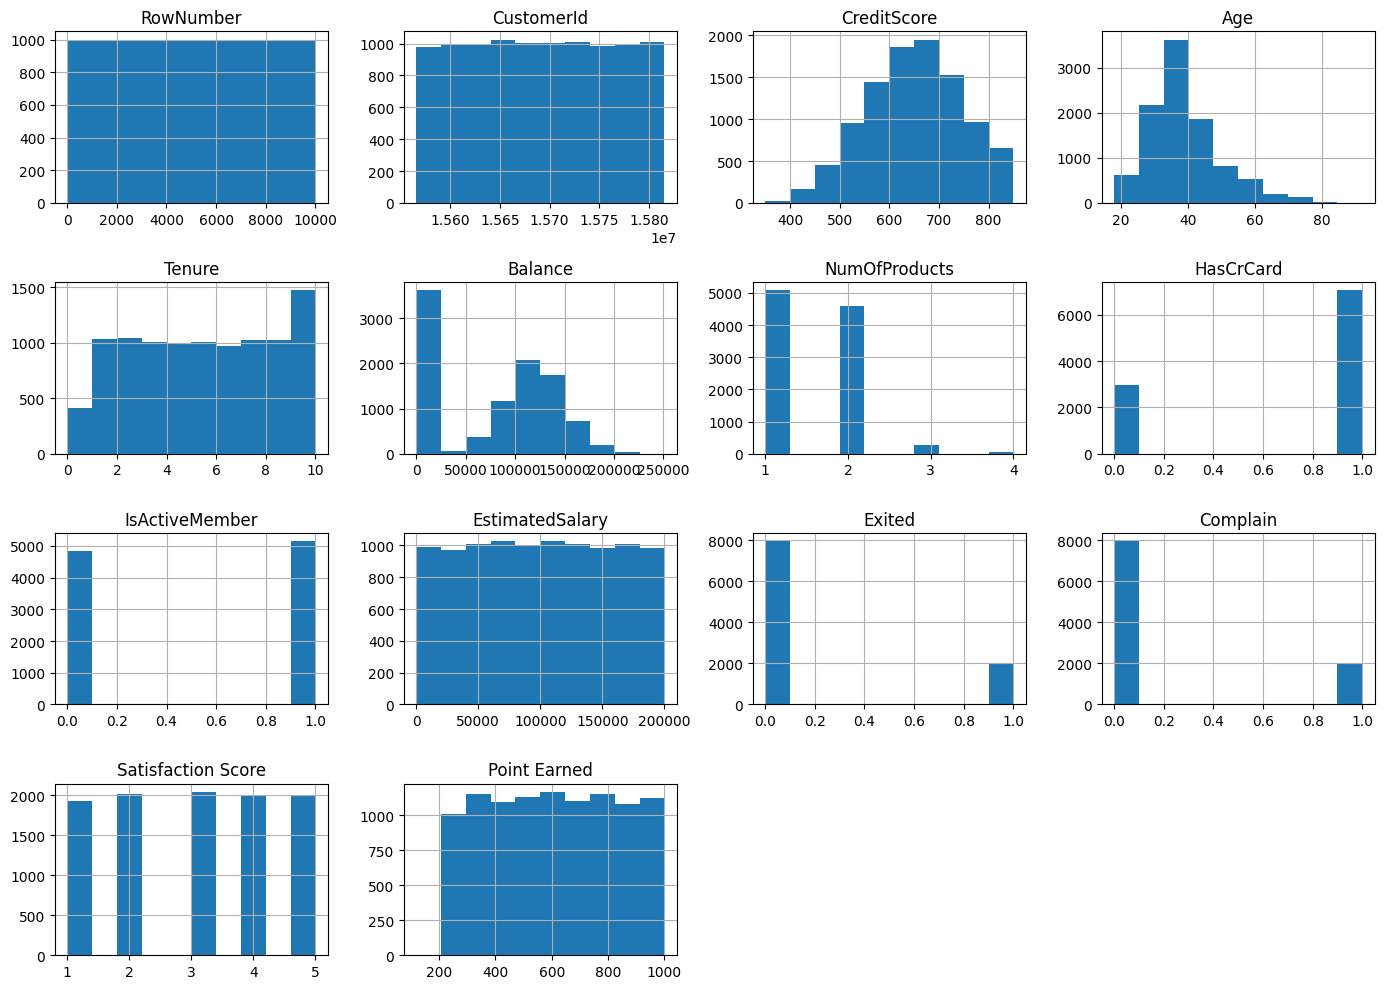

In [8]:
df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

# 2. Limpeza de Dados

**Observação do Professor:**
Nesta etapa aplicamos duas ações principais:

**1. Remoção de colunas irrelevantes:** `RowNumber`, `CustomerId` e `Surname` são identificadores administrativos. Eles não carregam nenhuma informação sobre o comportamento do cliente — são apenas "etiquetas" do sistema. A regra de ouro é clara: **"IDs não preveem comportamento"**. Mantê-los contaminaria o modelo com ruído.

**2. Remoção de duplicatas:** Boa prática para evitar viés no treinamento.

Como o dataset é muito limpo (sem nulos), não precisamos de imputação neste caso — uma situação diferente do Titanic clássico e do Spaceship Titanic!

In [9]:
# Remove colunas sem valor preditivo (IDs e identificadores pessoais)
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Remove duplicatas
df = df.drop_duplicates()

print(f'Shape após limpeza: {df.shape}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')
df.head()

Shape após limpeza: (10000, 15)
Nulos restantes: 0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


**Observação do Professor - Por que remover RowNumber, CustomerId e Surname?**

Esse é um dos erros mais comuns de iniciantes em Machine Learning: incluir identificadores no treinamento do modelo.

**O problema:** O algoritmo tentará encontrar padrões em qualquer coluna fornecida. Se incluirmos o `CustomerId`, ele aprenderá que "o cliente de ID 15634602 saiu do banco" — uma informação que **nunca se repetirá** para novos clientes. O modelo se tornará um memorizador de casos históricos em vez de um identificador de padrões reais.

**A regra de ouro:** Pergunte sempre — *"Essa informação estará disponível quando eu precisar prever o comportamento de um cliente novo?"*
- `CustomerId`: Não — cada novo cliente terá um ID diferente.
- `Surname`: Não — o sobrenome não determina se alguém vai sair do banco.
- `Age`, `Balance`, `Geography`: **Sim!** Essas características são conhecidas para qualquer cliente, novo ou antigo.

💡 **Regra de Ouro:** Nunca inclua identificadores únicos (IDs), nomes ou timestamps de criação como features preditivas.

# 3. Tratamento de Outliers

**Observação do Professor - Tratamento de Outliers (Método IQR):**

Aqui tratamos outliers nas features contínuas com maior risco: `CreditScore`, `Age` e `Balance`. Aplicamos o consagrado **Método IQR (Intervalo Interquartil)**:

- Calculamos o **Quartil 1 (25%)** e o **Quartil 3 (75%)**.
- A diferença entre eles é o **IQR (Intervalo)**.
- O limite aceito fica dentro de `1.5 * IQR` acima e abaixo dos quartis.
- Tudo que ultrapassar essas "cercas" é considerado outlier e removido.

**Por que não tratar `Balance`?** O `Balance` apresenta uma distribuição **bimodal legítima** (muitos zeros + distribuição de altos saldos). Esse padrão reflete a realidade do negócio bancário — muitos clientes mantêm conta sem saldo significativo. Removê-los como outlier seria um erro conceitual.

**Por que não tratar `EstimatedSalary`?** Apresenta distribuição uniforme por design — todos os valores são igualmente válidos dentro do intervalo.

![Tratamento de Outliers (IQR)](../aula-01-prepa-dados/image/outliers.jpg)

In [10]:
outlier_cols = ['CreditScore', 'Age']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)  # calcula o primeiro quartil
    Q3 = df[col].quantile(0.75)  # calcula o terceiro quartil
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR      # margem de tolerância inferior
    upper = Q3 + 1.5 * IQR      # margem de tolerância superior
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f'Shape após remoção de outliers: {df.shape}')

Shape após remoção de outliers: (9626, 15)


# 4. Transformações Estatísticas

**Observação do Professor:**
Neste dataset de Churn Bancário, **não há necessidade de transformação logarítmica** — as distribuições das features numéricas não apresentam a assimetria extrema à direita que observamos nos gastos do Spaceship Titanic.

No entanto, o `StandardScaler` é **absolutamente obrigatório** aqui. O motivo é a enorme discrepância de escalas entre as features:

- `Tenure` varia de 0 a 10 (escala de dezenas)
- `Balance` varia de 0 a ~250.000 (escala de centenas de milhar)
- `EstimatedSalary` varia de 0 a ~200.000 (escala de centenas de milhar)

O `StandardScaler` coloca todas as features na mesma escala (média 0, desvio padrão 1), impedindo que features com valores grandes dominem artificialmente o modelo. Isso é especialmente crítico para algoritmos como **Regressão Logística**, **KNN**, **SVM** e **Redes Neurais**.

In [11]:
# Features numéricas contínuas que precisam de padronização
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

df[numeric_features].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,9626.00,9626.00,9626.00,9626.00,9626.00,9626.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.79,-2.25,-1.74,-1.23,-0.91,-1.74
25%,-0.69,-0.66,-0.70,-1.23,-0.91,-0.85
50%,0.01,-0.09,-0.01,0.33,-0.91,0.00
75%,0.69,0.59,0.69,0.82,0.81,0.86
max,2.07,2.75,1.73,2.79,4.25,1.74


# 5. Encoding

**Observação do Professor:**
Nesta etapa realizamos o **Encoding** das variáveis categóricas para que os algoritmos de Machine Learning possam processá-las.

**One-Hot Encoding** (`pd.get_dummies`) com `drop_first=True`:
- **`Geography`** (3 categorias: `France`, `Germany`, `Spain`): Gera 2 novas colunas binárias (`Geography_Germany` e `Geography_Spain`). A categoria `France` fica implícita quando as duas outras são 0 — isso é o `drop_first=True` evitando a **armadilha da variável dummy**.
- **`Gender`** (2 categorias: `Male`/`Female`): Gera 1 nova coluna binária (`Gender_Male`). A categoria `Female` fica implícita quando `Gender_Male = 0`.

⚠️ **Importante:** `HasCrCard` e `IsActiveMember` já são colunas binárias (0/1) e **não** precisam de encoding — elas já estão no formato numérico ideal para os algoritmos.

In [12]:
# One-Hot Encoding para variáveis categóricas
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print(f'Shape após encoding: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head()

Shape após encoding: (9626, 16)
Colunas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain,Gender_Male
0,-0.330309,0.479282,-1.044601,-1.226774,-0.914163,1,1,0.021480,1,1,2,DIAMOND,464,False,False,False
1,-0.444790,0.365625,-1.390859,0.116386,-0.914163,0,1,0.216090,0,1,3,DIAMOND,456,False,True,False
2,-1.547974,0.479282,1.032946,1.332056,2.529285,1,0,0.240239,1,1,3,DIAMOND,377,False,False,False
3,0.502283,0.138311,-1.390859,-1.226774,0.807561,0,0,-0.109299,0,0,5,GOLD,350,False,False,False
4,2.073800,0.592939,-1.044601,0.784746,-0.914163,1,1,-0.365608,0,0,5,GOLD,425,False,True,False


# 6. Seleção de Features

**Observação do Professor:**
Utilizamos a função **`f_classif` (ANOVA F-test)** para identificar as features com maior poder discriminativo entre clientes que saem e os que ficam no banco.

A `f_classif` é a escolha correta aqui pois:
1. Lida corretamente com dados padronizados (que incluem valores negativos após o `StandardScaler`).
2. É adequada para problemas de **classificação** com variáveis contínuas.
3. Mede quão bem cada feature consegue **separar estatisticamente** as classes do target (`Exited`: 0 ou 1).

O `chi2` (Qui-Quadrado) seria inadequado aqui pois exige valores não-negativos — e após o `StandardScaler`, temos valores negativos por design.

In [13]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [16]:
# Converte variáveis categóricas em números
X_encoded = pd.get_dummies(X, drop_first=True)

selector = SelectKBest(score_func=f_classif, k=6)
X_new = selector.fit_transform(X_encoded, y)

selected_features = X_encoded.columns[selector.get_support()]

print('Features selecionadas:')
print(selected_features)

Features selecionadas:
Index(['Age', 'Balance', 'IsActiveMember', 'Complain', 'Geography_Germany',
       'Gender_Male'],
      dtype='str')


# 7. Split do Dataset

**Observação do Professor - Prevenção ao Vazamento de Dados (Data Leakage):**

Chegamos à separação do dataset! Aqui realizamos o `train_test_split` usando `stratify=y` — um parâmetro crucial quando há **desbalanceamento de classes**.

**Por que `stratify=y`?** Sem ele, em um dataset onde ~80% são classe 0 e ~20% são classe 1, um split aleatório poderia gerar um conjunto de teste com, por exemplo, 95% de classe 0. O modelo seria avaliado em uma amostra não representativa da realidade. Com `stratify=y`, garantimos que a proporção 80/20 seja mantida **tanto no treino quanto no teste**.

⚠️ **Lembrete para a prática:** Realizamos padronização ANTES do split — num contexto de produção real, o `StandardScaler` deve ser *fitado* apenas no treino e *aplicado* no teste. Em desafios mais avançados do curso, usaremos os `Pipelines` do `scikit-learn` para garantir isso.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded[selected_features], y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Distribuição do target no treino:\n{y_train.value_counts()}')
print(f'Percentual de Churn no treino: {y_train.mean()*100:.1f}%')

Treino: (7700, 6) | Teste: (1926, 6)
Distribuição do target no treino:
Exited
0    6140
1    1560
Name: count, dtype: int64
Percentual de Churn no treino: 20.3%


# Balanceamento com SMOTE

**Observação do Professor — Por que o SMOTE é CRÍTICO neste dataset:**

Este dataset possui um **desbalanceamento severo**: cerca de **80% dos clientes NÃO saem do banco** (classe 0) e apenas **~20% saem** (classe 1).

**O problema do desbalanceamento:** Se treinarmos um modelo sem balancear as classes, ele aprenderá a estratégia "preguiçosa" mais eficiente: **prever que ninguém sai do banco sempre**. Isso geraria uma acurácia ilusória de 80% — mas o modelo não detectaria *nenhum* cliente em risco de churn, tornando-o completamente inútil para o negócio!

**O SMOTE (Synthetic Minority Over-sampling Technique)** resolve isso gerando **amostras sintéticas** da classe minoritária (clientes que saem). Ao contrário do simples oversampling (que apenas duplica registros existentes), o SMOTE cria novos exemplos **interpolando** entre os pontos da classe minoritária, gerando uma distribuição mais rica e diversificada.

⚠️ **Regra Fundamental:** O SMOTE deve ser aplicado **APENAS no conjunto de treino** — nunca no conjunto de teste. Os dados de teste representam a realidade futura, e a realidade é desbalanceada. Avaliar o modelo em dados balanceados artificialmente seria fraudar a avaliação.

In [18]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f'Antes do SMOTE:  {X_train.shape}')
print(f'Após o SMOTE:    {X_train_balanced.shape}')
print()
print('Distribuição após SMOTE (treino balanceado):')
print(pd.Series(y_train_balanced).value_counts())
print(f'Percentual de Churn após SMOTE: {pd.Series(y_train_balanced).mean()*100:.1f}%')

Antes do SMOTE:  (7700, 6)
Após o SMOTE:    (12280, 6)

Distribuição após SMOTE (treino balanceado):
Exited
0    6140
1    6140
Name: count, dtype: int64
Percentual de Churn após SMOTE: 50.0%
